**IMPORT LIBARIES**

In [18]:
IDX = 1251

In [19]:
import multiprocessing as mp
import pickle as pkl
import albumentations as alb
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Sampler, Dataset
from datasets import load_from_disk
from collections import defaultdict
from typing import List, Iterator
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

**GLOBAL CONFIGURATIONS**

In [20]:
NUM_WORKERS = mp.cpu_count()
SEED = 2026

# 1. DATA PREPARATION

## 1.1. Configurations

In [21]:
START_TOKEN_ID = 0
PAD_TOKEN_ID = 1
END_TOKEN_ID = 2
UNK_TOKEN_ID = 3

## 1.2. Load data

### 1.2.1. Utils

In [22]:
class Vocab:
    def __init__(self):
        self.sign2id = {
            "<s>": START_TOKEN_ID,
            "</s>": END_TOKEN_ID,
            "<pad>": PAD_TOKEN_ID,
            "<unk>": UNK_TOKEN_ID,
        }
        self.id2sign = dict((idx, token) for token, idx in self.sign2id.items())
        self.length = 4

    def add_sign(self, sign):
        if sign not in self.sign2id:
            self.sign2id[sign] = self.length
            self.id2sign[self.length] = sign
            self.length += 1

    def __len__(self) -> int:
        return self.length

In [23]:
def load_vocab(filepath: str) -> Vocab:
    with open(filepath, "rb") as f:
        vocab: Vocab = pkl.load(f)
    print(f"Load vocab including {len(vocab)} Latex tokens.")
    return vocab

### 1.2.2. Load data

In [24]:
vocab = load_vocab("/kaggle/input/im2latex-100k/vocab.pkl")
vocab_size = len(vocab)

Load vocab including 394 Latex tokens.


## 1.3. Create DataLoader

### 1.3.1. Configurations

### 1.3.2 Utils

In [25]:
train_transform = alb.Compose(
    [
        # Geometric
        alb.Compose(
            [
                alb.Affine(
                    scale=(0.8, 1.05),      
                    rotate=(-2, 2),         
                    shear=(-2, 2),           
                    border_mode=0,
                    interpolation=4,   
                    fill=[255, 255, 255],
                    p=0.5,
                ),
                alb.Perspective(
                    scale=(0.005, 0.018),
                    border_mode=0,
                    fill=[0, 0, 0],
                    p=0.5
                ),
            ],
            p=0.5
        ),
        
        # Font thickness
        alb.OneOf([
            alb.Morphological(scale=[1, 2], operation="erosion", p=1.0),
            alb.Morphological(scale=[1, 1.5], operation="dilation", p=1.0)
        ], p=0.6),
        
        # Color variations TRƯỚC khi ToGray - để tạo diversity trong grayscale
        alb.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=10,
            p=0.5
        ),
        
        # Lighting variations
        alb.RandomBrightnessContrast(
            brightness_limit=0.1, 
            contrast_limit=(-0.3, 0.1), 
            p=0.7
        ),  
        
        # Quality degradation
        alb.ImageCompression(quality_range=(85, 95), p=0.5), 
        alb.Downscale(scale_range=[0.7, 0.95], interpolation_pair={"upscale":4,"downscale":3}, p=0.3),
        
        # Noise and blur
        alb.GaussNoise(std_range=(0.02, 0.17), p=0.2),
        alb.GaussianBlur(sigma_limit=(0.1, 0.5), p=0.3),  
        
        # Convert to grayscale
        alb.ToGray(p=1.0),
        alb.Normalize(mean=(0.9491, 0.9491, 0.9491), std=(0.1846, 0.1846, 0.1846)),
        ToTensorV2(),
    ], seed=SEED
)

In [26]:
def train_transforms(batch):
    images = []
    for img in batch["image"]:
        img_array = np.array(img)
        augmented = train_transform(image=img_array)
        images.append(augmented['image'])
    batch["image"] = images
    return batch

In [27]:
class SmartBucketSampler(Sampler):
    def __init__(
        self,
        data_source: Dataset,
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        seed: int = None,
    ):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.seed = seed
        self.epoch = 0  # To keep track of epochs

        # Create the buckets based on image sizes (w, h)
        self.buckets = defaultdict(list)
        print("Initializing Sampler... (Loading sizes)")

        # Assume data_source is a HuggingFace dataset or dict with 'width', 'height'
        # If it's a list of custom objects, you need to modify the access method
        widths = data_source["width"]
        heights = data_source["height"]

        for idx, (w, h) in enumerate(zip(widths, heights)):
            self.buckets[(w, h)].append(idx)

        print(f"Sampler initialized. Found {len(self.buckets)} unique buckets.")

        self.total_batches = 0
        for indices in self.buckets.values():
            self.total_batches += len(indices) // self.batch_size
            if not self.drop_last and len(indices) % self.batch_size != 0:
                self.total_batches += 1

    def __iter__(self) -> Iterator[List[int]]:
        batches = []

        if self.seed is not None:
            generator_seed = self.seed + self.epoch
            rng = random.Random(generator_seed)
        else:
            rng = random

        bucket_keys = list(self.buckets.keys())

        if self.shuffle:
            rng.shuffle(bucket_keys)

        for key in bucket_keys:
            # Copy list indices to avoid modifying the original data
            indices = self.buckets[key][:]

            if self.shuffle:
                rng.shuffle(indices)

            # Split into chunks
            for i in range(0, len(indices), self.batch_size):
                batch = indices[i : i + self.batch_size]

                if len(batch) == self.batch_size:
                    batches.append(batch)
                elif not self.drop_last:
                    batches.append(batch)

        if self.shuffle:
            rng.shuffle(batches)

        for batch in batches:
            yield batch

    def __len__(self) -> int:
        return self.total_batches

    def set_epoch(self, epoch: int) -> None:
        self.epoch = epoch

In [28]:
def collate_fn(batch):
    imgs = [item['image'] for item in batch]
    formulas = []
    
    for item in batch:
        tokens = item['formula'].split()
        formula_indices = [
            vocab.sign2id.get(token, vocab.sign2id["<unk>"]) 
            for token in tokens
        ]
        formula_indices = (
            [vocab.sign2id["<s>"]] + formula_indices + [vocab.sign2id["</s>"]]
        )
        formulas.append(torch.tensor(formula_indices, dtype=torch.long))
    
    imgs = torch.stack(imgs)
    formulas = pad_sequence(
        formulas, batch_first=True, padding_value=vocab.sign2id["<pad>"]
    )
    
    return imgs, formulas

### 1.3.2. Setup sampler

In [29]:
processed_dataset = load_from_disk("/kaggle/input/im2latex-100k/dataset")

In [30]:
train_dataset = processed_dataset['train'].select([IDX])
train_dataset.set_transform(train_transforms)

In [31]:
train_sampler = SmartBucketSampler(
    train_dataset,
    batch_size=1,
    shuffle=False,
    drop_last=True,
    seed=SEED,
)

Initializing Sampler... (Loading sizes)
Sampler initialized. Found 1 unique buckets.


### 1.3.3. DataLoader

In [32]:
def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed + worker_id)
    random.seed(worker_seed + worker_id)

In [33]:
worker_init = seed_worker

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    collate_fn=collate_fn,
    num_workers=4, 
    pin_memory=False,
    worker_init_fn=seed_worker, 
    persistent_workers=True,
)

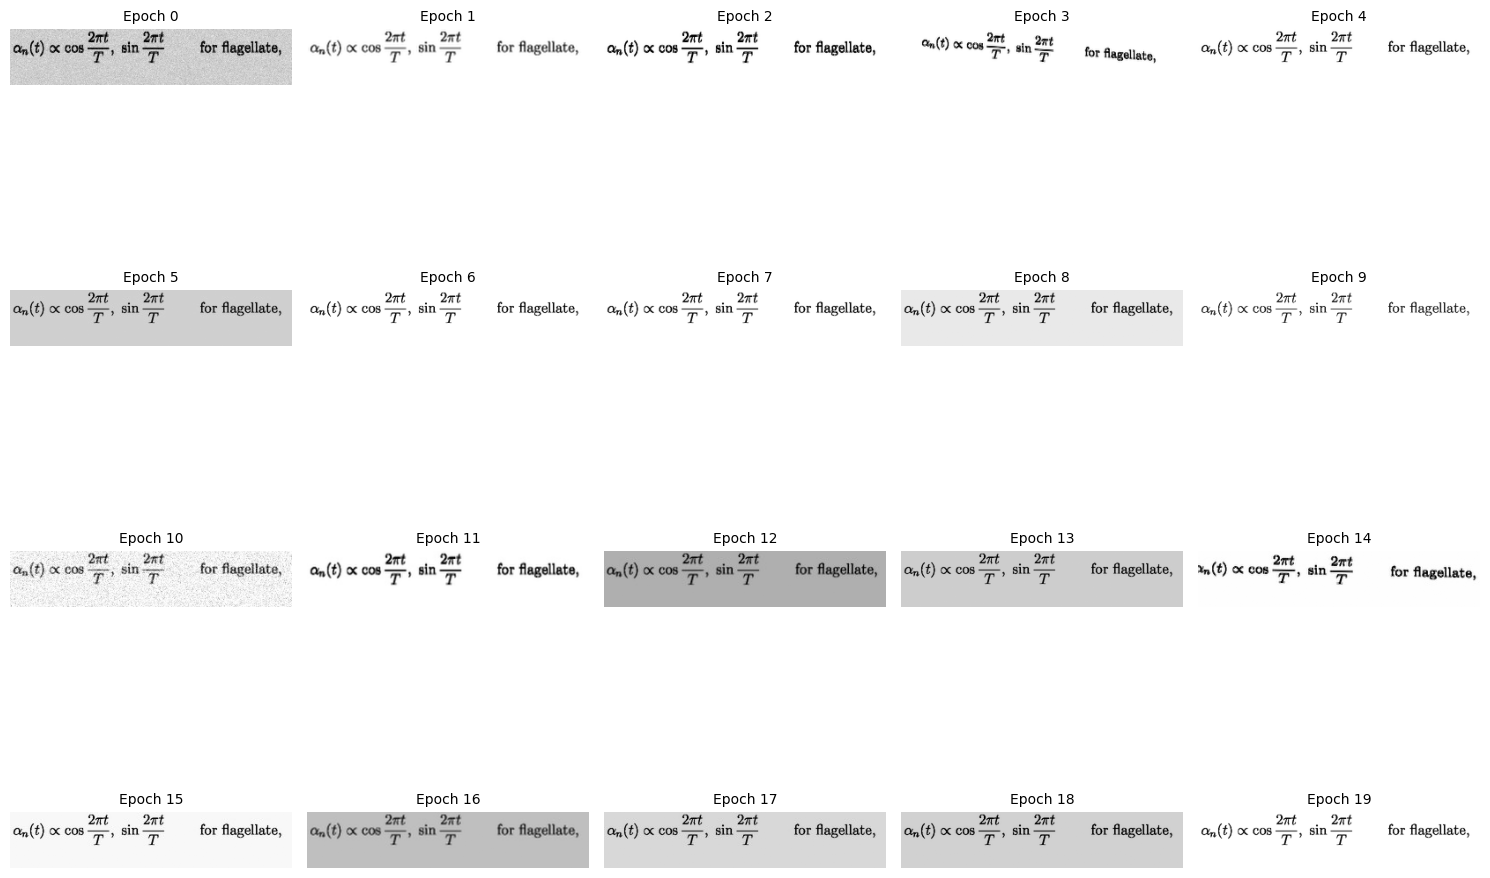

In [34]:
def visualize_denorm_epochs(
    train_loader,
    mean=(0.9491, 0.9491, 0.9491),
    std=(0.1846, 0.1846, 0.1846),
    N=12,
    max_cols=5
):
    mean = torch.tensor(mean)
    std = torch.tensor(std)

    display_list = []

    for epoch in range(N):
        if hasattr(train_loader.batch_sampler, "set_epoch"):
            train_loader.batch_sampler.set_epoch(epoch)

        for batch in train_loader:
            img = batch[0][0]  # (C, H, W)

            # ---- denormalize ----
            img = img * std[:, None, None] + mean[:, None, None]
            img = img.clamp(0, 1)

            img = img.permute(1, 2, 0).cpu().numpy()
            display_list.append(img)
            break  # mỗi epoch lấy 1 ảnh

    # -------- plot --------
    num_items = len(display_list)
    rows = (num_items + max_cols - 1) // max_cols

    fig, axes = plt.subplots(rows, max_cols, figsize=(15, rows * 3))
    axes = axes.flatten()

    for i, img in enumerate(display_list):
        axes[i].imshow(img, vmin=0, vmax=1)
        axes[i].set_title(f"Epoch {i}", fontsize=10)
        axes[i].axis("off")

    for j in range(num_items, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

visualize_denorm_epochs(
    train_loader,
    mean=(0.9491, 0.9491, 0.9491),
    std=(0.1846, 0.1846, 0.1846),
    N=20,
    max_cols=5
)